# Análise de Séries Temporais e Detecção de Anomalias Estruturais
**Estudo de Caso:** O Descolamento da Nvidia (NVDA) no Mercado de Semicondutores (2018 - 2025)

## 1. Introdução e Objetivo do Projeto
Este projeto utiliza redes neurais recorrentes (LSTM e GRU) para realizar uma análise de inferência causal sobre o preço das ações da Nvidia. O foco central não é a previsão de valores futuros, mas a construção de um modelo de base (*baseline*) que represente o comportamento histórico da empresa em relação ao seu setor.

A hipótese central é que, a partir de 2023, houve uma ruptura no padrão de precificação da Nvidia, descolando-a das métricas tradicionais do mercado de hardware gráfico. Ao comparar o valor real com a estimativa do modelo, quantificamos a magnitude dessa anomalia estrutural.

### Definição das Variáveis (Datasets):

Para que a análise seja robusta, integramos três conjuntos de dados distintos que fornecem o contexto completo do mercado:

1. **Nasdaq 100 (`^NDX`) - Contexto Macroeconômico**: Representa o desempenho das 100 maiores empresas de tecnologia. Serve como um indicador de controle para o otimismo ou pessimismo geral do setor tecnológico global.

2. **AMD (`AMD`) - Contexto Setorial (Benchmark)**: A AMD é a concorrente direta da Nvidia. Este dataset funciona como uma variável de controle setorial: se ambos os ativos sobem, o movimento é considerado um padrão do setor; se apenas a Nvidia apresenta alta desproporcional, identifica-se uma anomalia específica.

3. **Nvidia (`NVDA`) - Variável Alvo (Target)**: Objeto central do estudo. O modelo aprende o relacionamento desta variável com as outras duas entre 2018 e 2022 para identificar desvios e quebras de padrão no período posterior.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

start_date = "2018-01-01"
end_date = "2025-12-31"

df_nasdaq = yf.download("^NDX", start=start_date, end=end_date)[['Close']].rename(columns={'Close': 'Nasdaq'})
df_amd = yf.download("AMD", start=start_date, end=end_date)[['Close']].rename(columns={'Close': 'AMD'})
df_nvda = yf.download("NVDA", start=start_date, end=end_date)[['Close']].rename(columns={'Close': 'Nvidia'})

df = df_nasdaq.join(df_amd, how='inner').join(df_nvda, how='inner').dropna()
display(df.tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Nasdaq,AMD,Nvidia
Ticker,^NDX,AMD,NVDA
Date,,,
2025-12-23,25587.830078,214.899994,189.199768
2025-12-24,25656.150391,215.039993,188.599792
2025-12-26,25644.390625,214.990005,190.519684
2025-12-29,25525.560547,215.610001,188.209808
2025-12-30,25462.560547,215.339996,187.529846


## 2. Análise de Crescimento Relativo (Base 100)
Nesta visualização, normalizamos os preços para que todos iniciem no valor 100 em 2018. Isso permite comparar a velocidade de crescimento de ativos com preços nominais diferentes.

**Análise:** Observa-se que até o final de 2022, os três ativos apresentavam tendências de crescimento e retração sincronizadas. A partir de 2023, a Nvidia apresenta uma aceleração exponencial que rompe a paridade histórica com a AMD e o índice Nasdaq.

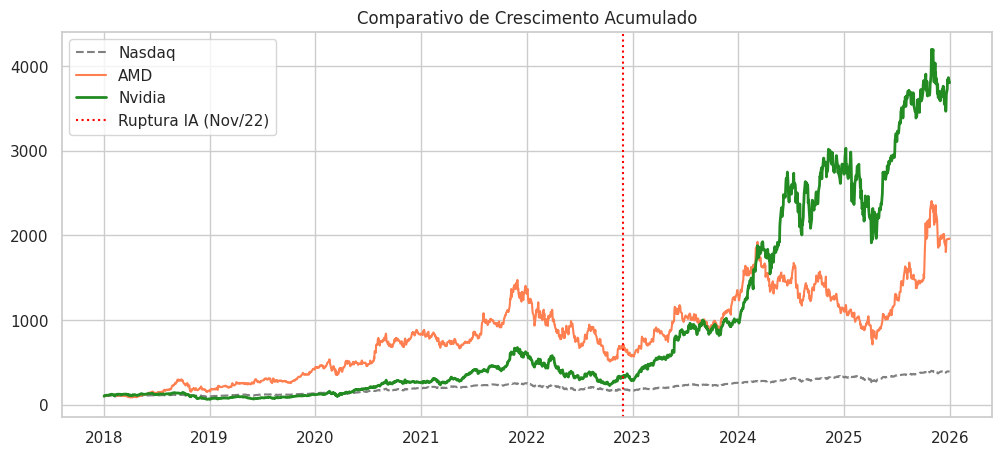

In [2]:
df_base100 = (df / df.iloc[0]) * 100
plt.figure(figsize=(12, 5))
plt.plot(df_base100['Nasdaq'], label='Nasdaq', color='gray', linestyle='--')
plt.plot(df_base100['AMD'], label='AMD', color='coral')
plt.plot(df_base100['Nvidia'], label='Nvidia', color='forestgreen', linewidth=2)
plt.axvline(pd.to_datetime('2022-11-30'), color='red', linestyle=':', label='Ruptura IA (Nov/22)')
plt.title('Comparativo de Crescimento Acumulado')
plt.legend()
plt.show()

## 3. Correlação Deslizante (Rolling Correlation)
Este gráfico utiliza uma janela móvel de 90 dias para calcular o Coeficiente de Correlação de Pearson entre Nvidia e AMD.

**Análise:** Valores acima de 0.8 indicam que os ativos respondem aos mesmos estímulos de mercado. A queda acentuada da correlação após 2022 confirma matematicamente que a precificação da Nvidia passou a depender de fatores exclusivos, desvinculando-se do comportamento da sua principal concorrente.

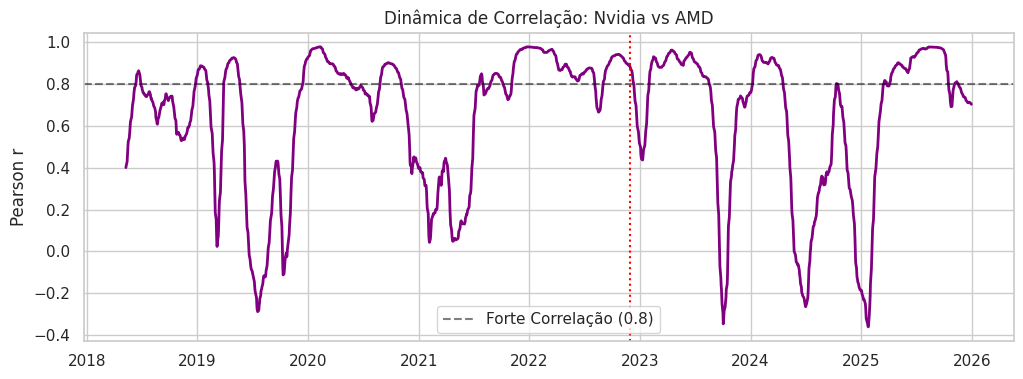

In [3]:
s_nvda = df['Nvidia'].squeeze().astype(float)
s_amd = df['AMD'].squeeze().astype(float)
rolling_corr = s_nvda.rolling(window=90).corr(s_amd)

plt.figure(figsize=(12, 4))
plt.plot(rolling_corr, color='purple', linewidth=2)
plt.axhline(0.8, color='black', linestyle='--', alpha=0.5, label='Forte Correlação (0.8)')
plt.axvline(pd.to_datetime('2022-11-30'), color='red', linestyle=':')
plt.title('Dinâmica de Correlação: Nvidia vs AMD')
plt.ylabel('Pearson r')
plt.legend()
plt.show()

## 4. Arquitetura do Modelo e Treinamento
O modelo foi configurado com camadas LSTM e GRU para capturar dependências temporais complexas. O treinamento foi realizado exclusivamente com dados do período de 2018 a 2022 (pré-anomalia), garantindo que a rede neural aprenda apenas a dinâmica de mercado anterior à expansão da IA Generativa.

In [4]:
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

data_corte = '2022-12-01'
df_treino = df[df.index < data_corte].copy()
df_teste = df[df.index >= data_corte].copy()

scaler = MinMaxScaler()
treino_s = scaler.fit_transform(df_treino)
teste_s = scaler.transform(df_teste)

def criar_seq(data, window=45):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window, 2])
    return np.array(X), np.array(y)

X_tr, y_tr = criar_seq(treino_s)
X_te, y_te = criar_seq(teste_s)

class ModeloRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(3, 64, batch_first=True)
        self.gru = nn.GRU(64, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out, _ = self.gru(out)
        return self.fc(out[:, -1, :])

model = ModeloRNN()
opt = optim.Adam(model.parameters(), lr=0.002)
crit = nn.MSELoss()

X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

for e in range(50):
    for xb, yb in loader:
        opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


## 5. Detecção de Descolamento Estrutural
Nesta fase, confrontamos as previsões do modelo com os dados reais de 2023 a 2025.

**Análise:** A linha azul representa o preço esperado caso a Nvidia mantivesse sua correlação histórica com a AMD e o Nasdaq. A divergência acentuada (área sombreada) quantifica a anomalia gerada pelo novo posicionamento da empresa no mercado de IA.

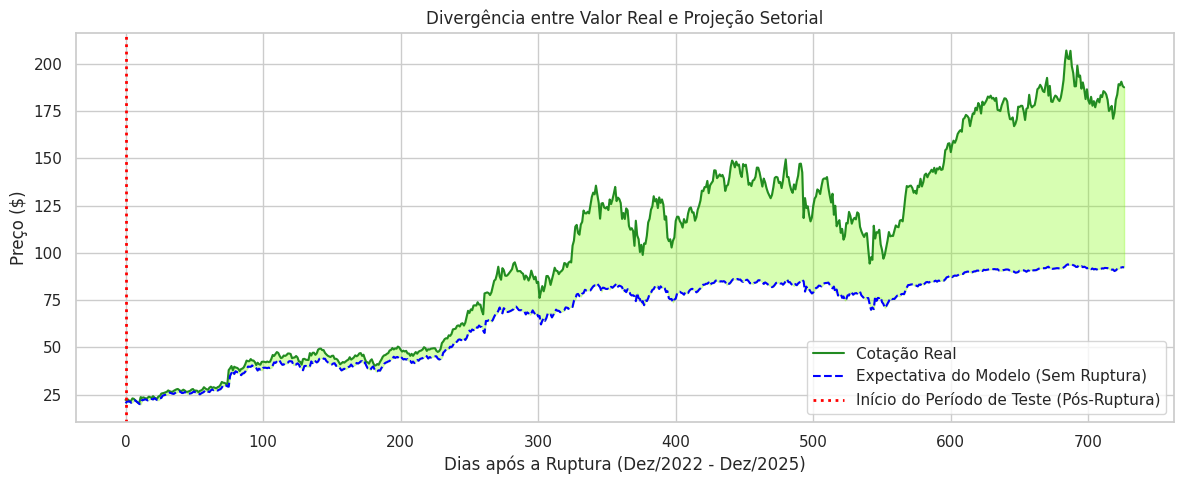

In [7]:
model.eval()
with torch.no_grad():
    preds = model(torch.tensor(X_te, dtype=torch.float32)).numpy()

m_falsa = np.zeros((len(preds), 3))
m_falsa[:, 2] = preds.flatten()
preds_reais = scaler.inverse_transform(m_falsa)[:, 2]

m_real = np.zeros((len(y_te), 3))
m_real[:, 2] = y_te.flatten()
real_nvda = scaler.inverse_transform(m_real)[:, 2]

plt.figure(figsize=(12, 5))
plt.plot(real_nvda, color='forestgreen', label='Cotação Real')
plt.plot(preds_reais, color='blue', linestyle='--', label='Expectativa do Modelo (Sem Ruptura)')
plt.fill_between(range(len(real_nvda)), preds_reais, real_nvda, color='lawngreen', alpha=0.3)

plt.axvline(x=0, color='red', linestyle=':', linewidth=2, label='Início do Período de Teste (Pós-Ruptura)')

plt.title('Divergência entre Valor Real e Projeção Setorial')
plt.xlabel('Dias após a Ruptura (Dez/2022 - Dez/2025)')
plt.ylabel('Preço ($)')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Análise de Resíduos e Densidade da Anomalia
Os resíduos representam a diferença numérica entre o valor real e a projeção do modelo. Em um cenário de estabilidade estrutural, a densidade de densidade de kernel (KDE) deveria estar centralizada no zero.

**Análise:** O deslocamento total da distribuição para a direita do eixo zero confirma um viés positivo persistente. Isso demonstra que a valorização da Nvidia não é um ruído estatístico temporário, mas uma mudança permanente de patamar estrutural.

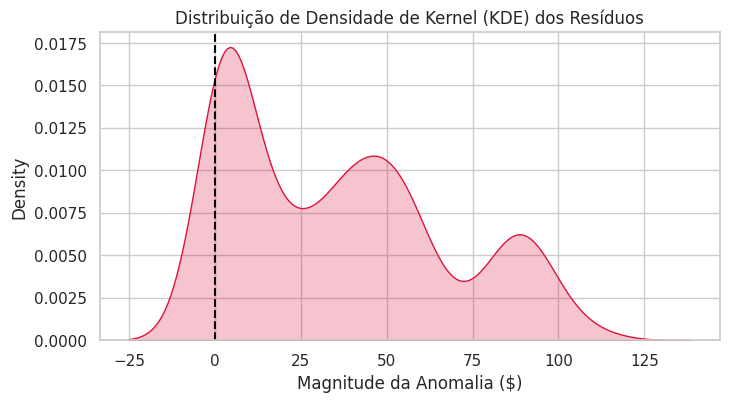

In [6]:
residuos = real_nvda - preds_reais
plt.figure(figsize=(8, 4))
sns.kdeplot(residuos, color='crimson', fill=True)
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribuição de Densidade de Kernel (KDE) dos Resíduos')
plt.xlabel('Magnitude da Anomalia ($)')
plt.show()

## 7. Conclusão Final
A aplicação de Deep Learning confirmou a quebra da cointegração histórica entre a Nvidia e seus pares setoriais. A magnitude da anomalia identificada no período de 2023-2025 comprova que os fundamentos de precificação da empresa sofreram uma mutação estrutural, impulsionada pela demanda global em infraestrutura de Inteligência Artificial.